In [1]:
import numpy as np
import scipy as sp
import helper as h
from functools import partial
import matplotlib.pyplot as plt
import pandas as pd
import os

import torch
import torch.nn as nn


In [2]:
%reload_ext autoreload
%autoreload 2

# residualized returns

In [3]:
import pickle

with open("gcv_train_30.pkl", "rb") as f:
    gcv_train = pickle.load(f).to_numpy()

with open("gcv_test_30.pkl", "rb") as f:
    gcv_test = pickle.load(f).to_numpy()

In [4]:
n, p = 493, 493
r, s = 1, 1

X_train = gcv_train # h.gaussian_sample(n, p)[0]
# results_array = [None for _ in range(4)]

np.random.seed(0)
beta = h.beta_sampler(p, r = np.sqrt(n) * r)
# have to rescale to keep distribution the same
X_test = gcv_test # np.random.normal(size = (1000, p)) / np.sqrt(n)
y_test = X_test @ beta
lambdas = np.logspace(-1, 2, 30)


In [5]:

resid_ret_result_1 = h.gcv_test_pipeline(
    X_train = X_train,
    y_train = None,
    X_test = X_test,
    y_test = y_test,
    lambdas = lambdas,
    r = r,
    sigma = s,
    k = 0,
    true_beta = beta,
    n_iters = 10,
    oracle_test=False
)

Computing SVDs
Done computing SVDs
PCR Coefs: []
update
1.0000000000000002
0.8534591556158553
0.9615111178577405 0.9449646041501626
[]
PCR Coefs: []
update
1.0000000000000002
0.8534591556158553
1.1965386105810647 0.8818026922711781
[]
PCR Coefs: []
update
1.0000000000000002
0.8534591556158553
0.8734169179118287 0.9558282959844521
[]
PCR Coefs: []
update
1.0000000000000002
0.8534591556158553
1.2130701073592496 0.8542873382894985
[]
PCR Coefs: []
update
1.0000000000000002
0.8534591556158553
1.059689378459056 0.8663743745790959
[]
PCR Coefs: []
update
1.0000000000000002
0.8534591556158553
1.1807972807287734 1.015449209585812
[]
PCR Coefs: []
update
1.0000000000000002
0.8534591556158553
1.0426731057907979 1.0086560356167706
[]
PCR Coefs: []
update
1.0000000000000002
0.8534591556158553
1.1435680752273871 0.9858467067733567
[]
PCR Coefs: []
update
1.0000000000000002
0.8534591556158553
1.1007899456162078 0.9900382216405497
[]
PCR Coefs: []
update
1.0000000000000002
0.8534591556158553
1.231376

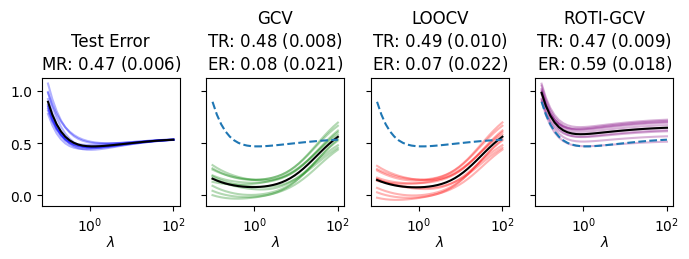

In [6]:
h.plot_results(resid_ret_result_1, lambdas, 1, None, square=False,)

## checks:
- well behaved spectrum
- signal alignment
- eigenvector coupling

In [7]:
Qt, d, O = np.linalg.svd(X_train)

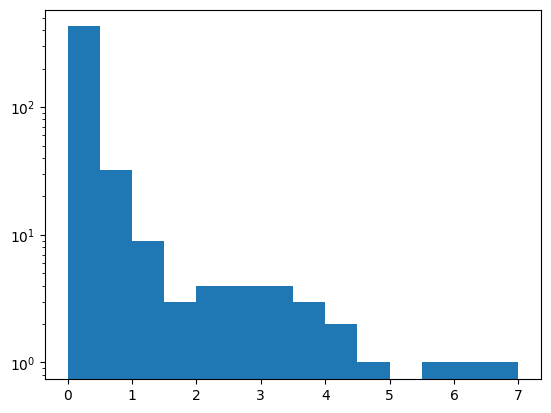

In [8]:
plt.hist(d, bins = np.linspace(0, 7, 15))
plt.yscale("log")

In [9]:
# plt.hist(O @ beta, bins = np.linspace(-4, 4, 81))
# plt.show()

In [10]:
Qt_test, d_test, O_test = np.linalg.svd(X_test)

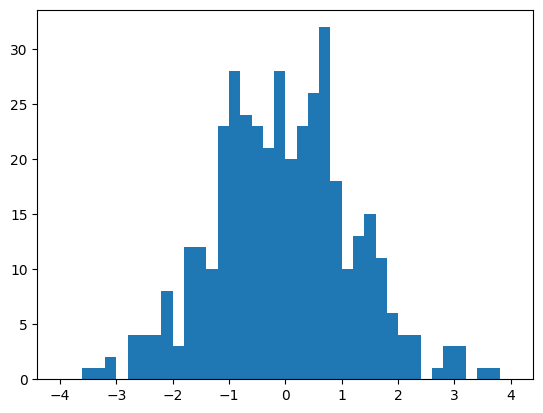

In [11]:
plt.hist((O_test[:20] @ O[:20].T).flatten()* np.sqrt(p), bins = np.linspace(-4, 4, 41))
plt.show()

In [12]:
def formatter(df, vmax = 10):
    return df.abs().round(2).rename(columns=lambda d: f"$o_{{{d + 1}}}$", index = lambda d: "$\\tilde" + "{o}" + f"_{{{d + 1}}}$",).T.style.background_gradient(cmap="Reds",vmin = 0, vmax = vmax).format("{{{:.2f}}}")

In [13]:

formatted_df = pd.DataFrame(O_test[:10] @ O[:10].T * np.sqrt(p)).abs().round(2).rename(columns=lambda d: f"$o_{{{d + 1}}}$", index = lambda d: "$\\tilde" + "{o}" + f"_{{{d + 1}}}$",).T.style.background_gradient(cmap="Reds",vmin = 0, vmax = 10).format("{{{:.2f}}}")
df_str = formatted_df.to_latex()
formatted_df

,$\tilde{o}_{1}$,$\tilde{o}_{2}$,$\tilde{o}_{3}$,$\tilde{o}_{4}$,$\tilde{o}_{5}$,$\tilde{o}_{6}$,$\tilde{o}_{7}$,$\tilde{o}_{8}$,$\tilde{o}_{9}$,$\tilde{o}_{10}$
$o_{1}$,{2.87},{2.02},{1.04},{2.18},{1.48},{1.37},{2.34},{0.58},{1.64},{2.30}
$o_{2}$,{0.31},{1.03},{0.15},{3.20},{0.78},{0.52},{0.82},{0.35},{0.43},{0.76}
$o_{3}$,{2.66},{3.17},{0.07},{1.42},{3.47},{0.44},{0.48},{0.98},{0.73},{1.01}
$o_{4}$,{0.20},{0.74},{2.73},{1.07},{0.85},{1.82},{0.46},{0.25},{0.76},{1.64}
$o_{5}$,{1.32},{0.12},{1.99},{1.66},{1.12},{1.75},{0.54},{0.40},{0.32},{1.81}
$o_{6}$,{2.37},{0.57},{1.70},{0.38},{1.26},{1.07},{0.63},{0.45},{0.39},{1.72}
$o_{7}$,{0.93},{1.86},{0.23},{0.84},{0.48},{0.02},{0.69},{0.02},{0.63},{1.41}
$o_{8}$,{4.12},{0.81},{2.57},{1.32},{1.52},{1.03},{0.88},{1.48},{0.72},{0.88}
$o_{9}$,{0.14},{1.01},{0.01},{1.17},{1.27},{2.43},{1.14},{0.45},{0.32},{1.12}
$o_{10}$,{0.02},{1.28},{1.64},{0.09},{0.94},{0.50},{0.42},{1.32},{0.34},{0.66}


In [14]:
print(df_str)

\begin{tabular}{lrrrrrrrrrr}
 & $\tilde{o}_{1}$ & $\tilde{o}_{2}$ & $\tilde{o}_{3}$ & $\tilde{o}_{4}$ & $\tilde{o}_{5}$ & $\tilde{o}_{6}$ & $\tilde{o}_{7}$ & $\tilde{o}_{8}$ & $\tilde{o}_{9}$ & $\tilde{o}_{10}$ \\
$o_{1}$ & \background-color#fcaf93 \color#000000 {2.87} & \background-color#fdcab5 \color#000000 {2.02} & \background-color#fee4d8 \color#000000 {1.04} & \background-color#fdc5ae \color#000000 {2.18} & \background-color#fedaca \color#000000 {1.48} & \background-color#fedccd \color#000000 {1.37} & \background-color#fcc1a8 \color#000000 {2.34} & \background-color#ffece3 \color#000000 {0.58} & \background-color#fdd5c4 \color#000000 {1.64} & \background-color#fcc2aa \color#000000 {2.30} \\
$o_{2}$ & \background-color#fff0e9 \color#000000 {0.31} & \background-color#fee4d8 \color#000000 {1.03} & \background-color#fff3ed \color#000000 {0.15} & \background-color#fca588 \color#000000 {3.20} & \background-color#fee8de \color#000000 {0.78} & \background-color#ffece4 \color#000000 {0.52}

In [15]:
import re

In [16]:
def replace_latex_colors(latex_code,):
    # Replace \background-color#hex with \cellcolor[HTML]{hex}
    latex_code = re.sub(
        r'\\background-color#([a-fA-F0-9]{6})',
        r'\\cellcolor[HTML]{\1}',
        latex_code
    )
    
    # Replace \color#hex with \textcolor[HTML]{hex}
    latex_code = re.sub(
        r'\\color#([a-fA-F0-9]{6}) ',
        r'\\textcolor[HTML]{\1}',
        latex_code
    )

    latex_code = latex_code.replace("lrrrrrrrrrr", "p{1.5em}C{2.5em}C{2.5em}C{2.5em}C{2.5em}C{2.5em}C{2.5em}C{2.5em}C{2.5em}C{2.5em}C{2.5em}")
    
    return "{\\tiny\n\setlength\\tabcolsep{1.5pt}\\renewcommand{\\arraystretch}{1.5}\n\sffamily\n" + latex_code + "}"



In [17]:
print(replace_latex_colors(df_str))

{\tiny
\setlength\tabcolsep{1.5pt}\renewcommand{\arraystretch}{1.5}
\sffamily
\begin{tabular}{p{1.5em}C{2.5em}C{2.5em}C{2.5em}C{2.5em}C{2.5em}C{2.5em}C{2.5em}C{2.5em}C{2.5em}C{2.5em}}
 & $\tilde{o}_{1}$ & $\tilde{o}_{2}$ & $\tilde{o}_{3}$ & $\tilde{o}_{4}$ & $\tilde{o}_{5}$ & $\tilde{o}_{6}$ & $\tilde{o}_{7}$ & $\tilde{o}_{8}$ & $\tilde{o}_{9}$ & $\tilde{o}_{10}$ \\
$o_{1}$ & \cellcolor[HTML]{fcaf93} \textcolor[HTML]{000000}{2.87} & \cellcolor[HTML]{fdcab5} \textcolor[HTML]{000000}{2.02} & \cellcolor[HTML]{fee4d8} \textcolor[HTML]{000000}{1.04} & \cellcolor[HTML]{fdc5ae} \textcolor[HTML]{000000}{2.18} & \cellcolor[HTML]{fedaca} \textcolor[HTML]{000000}{1.48} & \cellcolor[HTML]{fedccd} \textcolor[HTML]{000000}{1.37} & \cellcolor[HTML]{fcc1a8} \textcolor[HTML]{000000}{2.34} & \cellcolor[HTML]{ffece3} \textcolor[HTML]{000000}{0.58} & \cellcolor[HTML]{fdd5c4} \textcolor[HTML]{000000}{1.64} & \cellcolor[HTML]{fcc2aa} \textcolor[HTML]{000000}{2.30} \\
$o_{2}$ & \cellcolor[HTML]{fff0e9} \text

# speech data

In [18]:
from sklearn.datasets import fetch_openml
speech_data = fetch_openml(data_id =  40910)

p = 400
n = 400

data = speech_data['data'] / speech_data['data'].std()
data -= data.mean(0)
data = data / np.sqrt(n)
speech_train = data[:n].to_numpy()
speech_test = data[n:].to_numpy()

In [19]:
np.random.seed(0)
beta = h.beta_sampler(p, r = np.sqrt(n) * r)
# have to rescale to keep distribution the same
lambdas = np.logspace(-1, 2, 30)


In [20]:
match_dict = {
    0: 0,
    1: 1,
    2: 2,
    # 3: 5, 
    # 4: 4,
    # 5: 3,
    # 6: 6,
    # 7: 7,
    # 8: 8,
    # 9: 9,
}

matcher = lambda d: match_dict[d]

In [21]:

y_test = speech_test @ beta
lambdas = np.logspace(-1, 2, 30)
speech_result = h.gcv_test_pipeline(
    X_train = speech_train,
    y_train = None,
    X_test = speech_test,
    y_test = y_test,
    lambdas = lambdas,
    r = r,
    sigma = s,
    k = 3,
    true_beta = beta,
    n_iters = 10,
    oracle_test=False,
    matcher = matcher
)

Computing SVDs
Done computing SVDs
PCR Coefs: [0.36223541 0.08340348 0.56054421]
update
1.0000000000000002
0.9465136331394955
0.9606288445435596 1.0065776220194032
[0.36223541 0.08340348 0.56054421]
PCR Coefs: [-0.42633088 -0.32668767  0.43864127]
update
1.0000000000000002
0.9465136331394955
0.9127047684171299 0.8885900419686045
[-0.42633088 -0.32668767  0.43864127]
PCR Coefs: [-0.55878579 -0.04829432  0.53134585]
update
1.0000000000000002
0.9465136331394955
0.6406487546231728 1.0921071847599153
[-0.55878579 -0.04829432  0.53134585]
PCR Coefs: [ 0.26274736 -0.70969422  0.96845894]
update
1.0000000000000002
0.9465136331394955
0.9887595883674984 1.0339921974130968
[ 0.26274736 -0.70969422  0.96845894]
PCR Coefs: [-0.3020032   0.25112284  1.03463808]
update
1.0000000000000002
0.9465136331394955
0.8605876123519676 0.944634133061316
[-0.3020032   0.25112284  1.03463808]
PCR Coefs: [ 0.37799821 -0.16661935  0.90275832]
update
1.0000000000000002
0.9465136331394955
0.9858609177206199 0.8111286

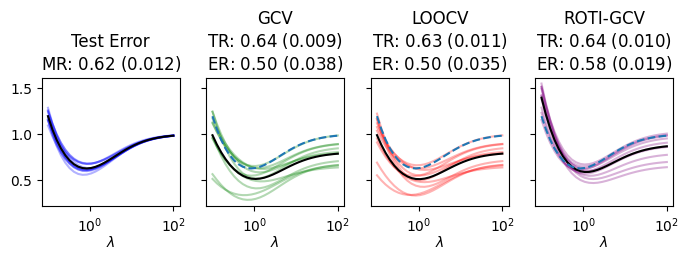

In [26]:
h.plot_results(speech_result, lambdas, 1, filename=None, square=False,)

## checks

In [27]:
Qt, d, O = np.linalg.svd(speech_train)
Qt_test, d_test, O_test = np.linalg.svd(speech_test)

(array([81., 73., 62., 53., 43., 34., 26., 17.,  7.,  3.,  0.,  0.,  1.,
         0.,  0.,  0.]),
 array([0.  , 0.25, 0.5 , 0.75, 1.  , 1.25, 1.5 , 1.75, 2.  , 2.25, 2.5 ,
        2.75, 3.  , 3.25, 3.5 , 3.75, 4.  ]),
 <BarContainer object of 16 artists>)

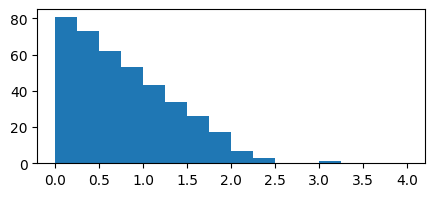

In [31]:
plt.figure(figsize=(5, 2))
plt.hist(d, bins = np.linspace(0, 4, 17))
# plt.yscale("log")

In [32]:
formatted = pd.DataFrame(np.arccos(np.abs(O_test[:10] @ O[:10].T)) / np.pi * 180).rename(columns=lambda d: f"$o_{d + 1}$", index = lambda d: "$\\tilde" + "{o}" + f"_{d + 1}$",).T.style.background_gradient(
    cmap = "Reds_r", vmin = 50, vmax = 90,
).format("${:.1f}^\circ$")
formatted

,$\tilde{o}_1$,$\tilde{o}_2$,$\tilde{o}_3$,$\tilde{o}_4$,$\tilde{o}_5$,$\tilde{o}_6$,$\tilde{o}_7$,$\tilde{o}_8$,$\tilde{o}_9$,$\tilde{o}_10$
$o_1$,$30.1^\circ$,$82.2^\circ$,$88.2^\circ$,$84.2^\circ$,$85.5^\circ$,$87.1^\circ$,$89.1^\circ$,$87.3^\circ$,$85.1^\circ$,$89.2^\circ$
$o_2$,$87.6^\circ$,$40.3^\circ$,$88.1^\circ$,$85.3^\circ$,$86.2^\circ$,$86.5^\circ$,$87.4^\circ$,$85.9^\circ$,$89.2^\circ$,$83.7^\circ$
$o_3$,$86.9^\circ$,$84.5^\circ$,$56.9^\circ$,$85.4^\circ$,$88.2^\circ$,$84.2^\circ$,$76.6^\circ$,$89.0^\circ$,$78.0^\circ$,$82.1^\circ$
$o_4$,$89.2^\circ$,$82.0^\circ$,$81.6^\circ$,$89.4^\circ$,$78.5^\circ$,$70.7^\circ$,$81.4^\circ$,$85.3^\circ$,$88.5^\circ$,$85.5^\circ$
$o_5$,$86.4^\circ$,$82.2^\circ$,$78.4^\circ$,$83.9^\circ$,$75.2^\circ$,$86.3^\circ$,$77.5^\circ$,$76.3^\circ$,$81.5^\circ$,$83.6^\circ$
$o_6$,$86.6^\circ$,$88.4^\circ$,$76.1^\circ$,$72.7^\circ$,$88.9^\circ$,$79.0^\circ$,$86.1^\circ$,$87.5^\circ$,$75.6^\circ$,$87.0^\circ$
$o_7$,$83.7^\circ$,$88.0^\circ$,$83.8^\circ$,$82.4^\circ$,$76.0^\circ$,$84.9^\circ$,$88.5^\circ$,$87.1^\circ$,$85.3^\circ$,$82.7^\circ$
$o_8$,$88.7^\circ$,$89.6^\circ$,$81.5^\circ$,$89.5^\circ$,$85.2^\circ$,$77.0^\circ$,$89.4^\circ$,$88.9^\circ$,$84.8^\circ$,$89.7^\circ$
$o_9$,$89.1^\circ$,$88.8^\circ$,$87.9^\circ$,$90.0^\circ$,$85.3^\circ$,$86.0^\circ$,$78.9^\circ$,$76.9^\circ$,$86.8^\circ$,$82.6^\circ$
$o_10$,$86.7^\circ$,$82.8^\circ$,$87.4^\circ$,$87.8^\circ$,$88.9^\circ$,$87.7^\circ$,$83.0^\circ$,$84.8^\circ$,$84.8^\circ$,$83.3^\circ$


In [33]:
df_str = formatted.to_latex(convert_css=False)

In [34]:
print(df_str)

\begin{tabular}{lrrrrrrrrrr}
 & $\tilde{o}_1$ & $\tilde{o}_2$ & $\tilde{o}_3$ & $\tilde{o}_4$ & $\tilde{o}_5$ & $\tilde{o}_6$ & $\tilde{o}_7$ & $\tilde{o}_8$ & $\tilde{o}_9$ & $\tilde{o}_10$ \\
$o_1$ & \background-color#67000d \color#f1f1f1 $30.1^\circ$ & \background-color#fdcbb6 \color#000000 $82.2^\circ$ & \background-color#ffeee6 \color#000000 $88.2^\circ$ & \background-color#fedbcc \color#000000 $84.2^\circ$ & \background-color#fee3d6 \color#000000 $85.5^\circ$ & \background-color#fee9df \color#000000 $87.1^\circ$ & \background-color#fff2eb \color#000000 $89.1^\circ$ & \background-color#feeae0 \color#000000 $87.3^\circ$ & \background-color#fee1d3 \color#000000 $85.1^\circ$ & \background-color#fff2ec \color#000000 $89.2^\circ$ \\
$o_2$ & \background-color#ffebe2 \color#000000 $87.6^\circ$ & \background-color#67000d \color#f1f1f1 $40.3^\circ$ & \background-color#ffede5 \color#000000 $88.1^\circ$ & \background-color#fee2d5 \color#000000 $85.3^\circ$ & \background-color#fee5d9 \color#0

In [35]:

pd.DataFrame(O_test[:10] @ O[:10].T * np.sqrt(p)).abs().round(2).style.background_gradient(cmap="Reds",vmin = 0, vmax = 10).format("{:.2f}")



,0,1,2,3,4,5,6,7,8,9
0,17.30,0.83,1.08,0.29,1.27,1.19,2.21,0.46,0.30,1.14
1,2.72,15.24,1.93,2.78,2.70,0.56,0.70,0.15,0.40,2.51
2,0.63,0.68,10.93,2.92,4.02,4.82,2.14,2.96,0.72,0.90
3,2.01,1.63,1.60,0.22,2.14,5.95,2.65,0.16,0.01,0.77
4,1.55,1.34,0.64,3.98,5.11,0.37,4.84,1.66,1.63,0.37
5,1.02,1.22,2.02,6.63,1.29,3.83,1.77,4.49,1.39,0.79
6,0.30,0.89,4.63,2.98,4.34,1.37,0.54,0.22,3.86,2.44
7,0.96,1.42,0.35,1.65,4.72,0.87,1.00,0.40,4.53,1.83
8,1.70,0.27,4.14,0.54,2.95,4.98,1.65,1.82,1.12,1.81
9,0.27,2.19,2.75,1.56,2.24,1.04,2.53,0.10,2.57,2.34


In [36]:
formatter(pd.DataFrame(O_test[:10] @ O[:10].T * np.sqrt(p)), vmax = 15)

,$\tilde{o}_{1}$,$\tilde{o}_{2}$,$\tilde{o}_{3}$,$\tilde{o}_{4}$,$\tilde{o}_{5}$,$\tilde{o}_{6}$,$\tilde{o}_{7}$,$\tilde{o}_{8}$,$\tilde{o}_{9}$,$\tilde{o}_{10}$
$o_{1}$,{17.30},{2.72},{0.63},{2.01},{1.55},{1.02},{0.30},{0.96},{1.70},{0.27}
$o_{2}$,{0.83},{15.24},{0.68},{1.63},{1.34},{1.22},{0.89},{1.42},{0.27},{2.19}
$o_{3}$,{1.08},{1.93},{10.93},{1.60},{0.64},{2.02},{4.63},{0.35},{4.14},{2.75}
$o_{4}$,{0.29},{2.78},{2.92},{0.22},{3.98},{6.63},{2.98},{1.65},{0.54},{1.56}
$o_{5}$,{1.27},{2.70},{4.02},{2.14},{5.11},{1.29},{4.34},{4.72},{2.95},{2.24}
$o_{6}$,{1.19},{0.56},{4.82},{5.95},{0.37},{3.83},{1.37},{0.87},{4.98},{1.04}
$o_{7}$,{2.21},{0.70},{2.14},{2.65},{4.84},{1.77},{0.54},{1.00},{1.65},{2.53}
$o_{8}$,{0.46},{0.15},{2.96},{0.16},{1.66},{4.49},{0.22},{0.40},{1.82},{0.10}
$o_{9}$,{0.30},{0.40},{0.72},{0.01},{1.63},{1.39},{3.86},{4.53},{1.12},{2.57}
$o_{10}$,{1.14},{2.51},{0.90},{0.77},{0.37},{0.79},{2.44},{1.83},{1.81},{2.34}


In [37]:
print(replace_latex_colors(formatter(pd.DataFrame(O_test[:10] @ O[:10].T * np.sqrt(p)), vmax = 15).to_latex()))

{\tiny
\setlength\tabcolsep{1.5pt}\renewcommand{\arraystretch}{1.5}
\sffamily
\begin{tabular}{p{1.5em}C{2.5em}C{2.5em}C{2.5em}C{2.5em}C{2.5em}C{2.5em}C{2.5em}C{2.5em}C{2.5em}C{2.5em}}
 & $\tilde{o}_{1}$ & $\tilde{o}_{2}$ & $\tilde{o}_{3}$ & $\tilde{o}_{4}$ & $\tilde{o}_{5}$ & $\tilde{o}_{6}$ & $\tilde{o}_{7}$ & $\tilde{o}_{8}$ & $\tilde{o}_{9}$ & $\tilde{o}_{10}$ \\
$o_{1}$ & \cellcolor[HTML]{67000d} \textcolor[HTML]{f1f1f1}{17.30} & \cellcolor[HTML]{fdd0bc} \textcolor[HTML]{000000}{2.72} & \cellcolor[HTML]{ffeee7} \textcolor[HTML]{000000}{0.63} & \cellcolor[HTML]{fedecf} \textcolor[HTML]{000000}{2.01} & \cellcolor[HTML]{fee4d8} \textcolor[HTML]{000000}{1.55} & \cellcolor[HTML]{feeae0} \textcolor[HTML]{000000}{1.02} & \cellcolor[HTML]{fff2eb} \textcolor[HTML]{000000}{0.30} & \cellcolor[HTML]{feeae1} \textcolor[HTML]{000000}{0.96} & \cellcolor[HTML]{fee2d5} \textcolor[HTML]{000000}{1.70} & \cellcolor[HTML]{fff2ec} \textcolor[HTML]{000000}{0.27} \\
$o_{2}$ & \cellcolor[HTML]{ffece3} \tex

# gaussian mixture

In [38]:
n, p = 1000, 1000
r, s = 1, 1

np.random.seed(1)

X_train = h.gaussian_mixture_sample(n, p, mu = 3)[0]
beta = h.beta_sampler(p, r = np.sqrt(n) * r)
# have to rescale to keep distribution the same
X_test = h.gaussian_mixture_sample(n, p, mu = 3)[0]
y_test = X_test @ beta
lambdas = np.logspace(-1, 1, 30)


In [39]:

gm_results = h.gcv_test_pipeline(
    X_train = X_train,
    y_train = None,
    X_test = X_test,
    y_test = y_test,
    lambdas = lambdas,
    r = r,
    sigma = s,
    k = 10,
    true_beta = beta,
    n_iters = 10,
    oracle_test=False
)

Computing SVDs
Done computing SVDs
PCR Coefs: [ 0.16485279  2.06418733 -0.81479485 -4.53892451  0.24138612 -1.2528588
 -2.57470983  0.07582841  1.36323532 -4.34453603]
update
1.0
0.31024444915988825
1.4497196566235402 0.9956056275714393
[ 0.16485279  2.06418733 -0.81479485 -4.53892451  0.24138612 -1.2528588
 -2.57470983  0.07582841  1.36323532 -4.34453603]
PCR Coefs: [ 0.16940721 -1.01280382 -2.18663215 -1.5438624  -0.05482152 -1.24415599
 -3.89402261 -0.1637457   3.18501263 -3.91447022]
update
1.0
0.31024444915988825
2.1423880209266994 0.903862024995549
[ 0.16940721 -1.01280382 -2.18663215 -1.5438624  -0.05482152 -1.24415599
 -3.89402261 -0.1637457   3.18501263 -3.91447022]
PCR Coefs: [ 0.12342279 -0.45374636 -5.7954846  -3.69539123  1.37286984  0.48788486
  1.14434275  0.21452401  1.39755976 -1.89959649]
update
1.0
0.31024444915988825
0.9311471114814395 1.0599444729607976
[ 0.12342279 -0.45374636 -5.7954846  -3.69539123  1.37286984  0.48788486
  1.14434275  0.21452401  1.39755976 -1.

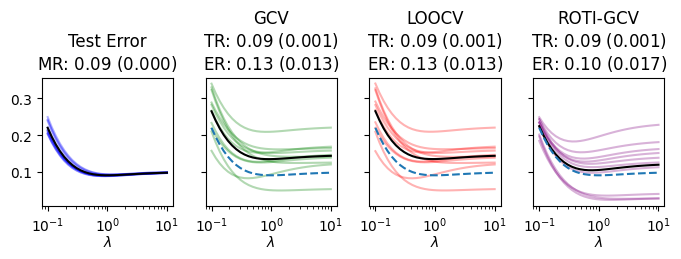

In [40]:
h.plot_results(gm_results, lambdas, 1, None, square=False,)

## checks

In [41]:
Qt, d, O = np.linalg.svd(X_train)
Qt_test, d_test, O_test = np.linalg.svd(X_test)

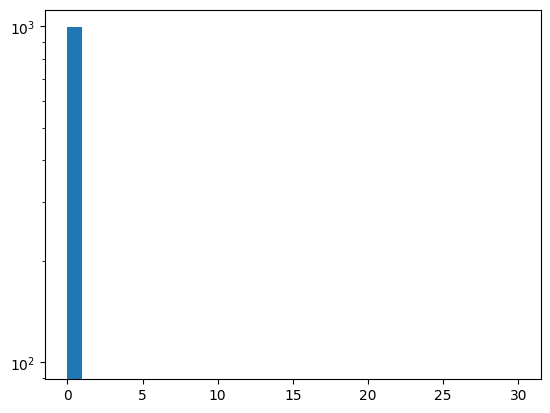

In [42]:
plt.hist(d, np.linspace(0, 30, 31))
plt.yscale("log")

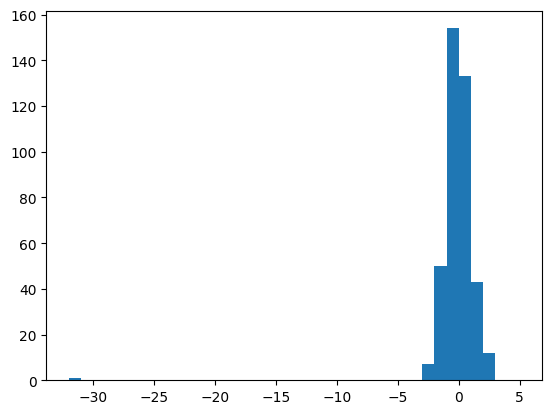

In [43]:
plt.hist((O_test[:20] @ O[:20].T).flatten()* np.sqrt(p), bins = np.linspace(-32, 5, 38))
plt.show()

In [44]:

pd.DataFrame(O_test[:10] @ O[:10].T * np.sqrt(p)).abs().round(2).style.background_gradient(cmap="Reds",vmin = 0, vmax = 10).format("{:.2f}")

,0,1,2,3,4,5,6,7,8,9
0,31.62,0.02,0.02,0.00,0.01,0.01,0.01,0.01,0.02,0.00
1,0.01,0.29,1.13,2.08,0.56,0.03,0.20,0.04,0.53,0.29
2,0.04,1.74,0.53,0.60,1.73,0.94,0.38,0.73,1.36,0.22
3,0.02,0.37,0.20,1.01,1.04,0.02,0.77,0.70,1.02,0.10
4,0.02,1.20,0.62,0.09,0.67,0.16,0.29,0.67,2.42,1.06
5,0.01,2.17,0.31,1.45,0.67,0.42,0.36,0.56,0.29,0.09
6,0.03,0.86,0.06,0.04,2.05,2.70,0.38,1.36,0.50,1.76
7,0.00,1.10,0.74,0.17,1.05,0.84,1.00,0.79,0.47,0.76
8,0.01,2.13,1.10,0.45,1.07,0.58,0.07,2.96,1.56,0.06
9,0.02,1.27,1.59,0.02,0.09,0.30,1.04,0.39,1.20,0.21


In [45]:
formatter(pd.DataFrame(O_test[:10] @ O[:10].T * np.sqrt(p)), vmax = 15)

,$\tilde{o}_{1}$,$\tilde{o}_{2}$,$\tilde{o}_{3}$,$\tilde{o}_{4}$,$\tilde{o}_{5}$,$\tilde{o}_{6}$,$\tilde{o}_{7}$,$\tilde{o}_{8}$,$\tilde{o}_{9}$,$\tilde{o}_{10}$
$o_{1}$,{31.62},{0.01},{0.04},{0.02},{0.02},{0.01},{0.03},{0.00},{0.01},{0.02}
$o_{2}$,{0.02},{0.29},{1.74},{0.37},{1.20},{2.17},{0.86},{1.10},{2.13},{1.27}
$o_{3}$,{0.02},{1.13},{0.53},{0.20},{0.62},{0.31},{0.06},{0.74},{1.10},{1.59}
$o_{4}$,{0.00},{2.08},{0.60},{1.01},{0.09},{1.45},{0.04},{0.17},{0.45},{0.02}
$o_{5}$,{0.01},{0.56},{1.73},{1.04},{0.67},{0.67},{2.05},{1.05},{1.07},{0.09}
$o_{6}$,{0.01},{0.03},{0.94},{0.02},{0.16},{0.42},{2.70},{0.84},{0.58},{0.30}
$o_{7}$,{0.01},{0.20},{0.38},{0.77},{0.29},{0.36},{0.38},{1.00},{0.07},{1.04}
$o_{8}$,{0.01},{0.04},{0.73},{0.70},{0.67},{0.56},{1.36},{0.79},{2.96},{0.39}
$o_{9}$,{0.02},{0.53},{1.36},{1.02},{2.42},{0.29},{0.50},{0.47},{1.56},{1.20}
$o_{10}$,{0.00},{0.29},{0.22},{0.10},{1.06},{0.09},{1.76},{0.76},{0.06},{0.21}


In [46]:
print(replace_latex_colors(formatter(pd.DataFrame(O_test[:10] @ O[:10].T * np.sqrt(p)), vmax = 15).to_latex()))

{\tiny
\setlength\tabcolsep{1.5pt}\renewcommand{\arraystretch}{1.5}
\sffamily
\begin{tabular}{p{1.5em}C{2.5em}C{2.5em}C{2.5em}C{2.5em}C{2.5em}C{2.5em}C{2.5em}C{2.5em}C{2.5em}C{2.5em}}
 & $\tilde{o}_{1}$ & $\tilde{o}_{2}$ & $\tilde{o}_{3}$ & $\tilde{o}_{4}$ & $\tilde{o}_{5}$ & $\tilde{o}_{6}$ & $\tilde{o}_{7}$ & $\tilde{o}_{8}$ & $\tilde{o}_{9}$ & $\tilde{o}_{10}$ \\
$o_{1}$ & \cellcolor[HTML]{67000d} \textcolor[HTML]{f1f1f1}{31.62} & \cellcolor[HTML]{fff5f0} \textcolor[HTML]{000000}{0.01} & \cellcolor[HTML]{fff5f0} \textcolor[HTML]{000000}{0.04} & \cellcolor[HTML]{fff5f0} \textcolor[HTML]{000000}{0.02} & \cellcolor[HTML]{fff5f0} \textcolor[HTML]{000000}{0.02} & \cellcolor[HTML]{fff5f0} \textcolor[HTML]{000000}{0.01} & \cellcolor[HTML]{fff5f0} \textcolor[HTML]{000000}{0.03} & \cellcolor[HTML]{fff5f0} \textcolor[HTML]{000000}{0.00} & \cellcolor[HTML]{fff5f0} \textcolor[HTML]{000000}{0.01} & \cellcolor[HTML]{fff5f0} \textcolor[HTML]{000000}{0.02} \\
$o_{2}$ & \cellcolor[HTML]{fff5f0} \tex

# poorly behaved example

Here, the top eigenvectors overlap but not in a way covered by our alignment theory. In particular, they correlate with each other but not perfectly so.

In [47]:
import pickle

with open("gcv_train_30_no_remove.pkl", "rb") as f:
    gcv_train = pickle.load(f).to_numpy()

with open("gcv_test_30_no_remove.pkl", "rb") as f:
    gcv_test = pickle.load(f).to_numpy()

In [48]:
map_dict_2 = {
    0: 0,
    1: 1,
    2: 2
}

In [ ]:
n, p = 493, 493
r, s = 1, 1

X_train = gcv_train # h.gaussian_sample(n, p)[0]
np.random.seed(0)
beta = h.beta_sampler(p, r = np.sqrt(n) * r)
# have to rescale to keep distribution the same
X_test = gcv_test # np.random.normal(size = (1000, p)) / np.sqrt(n)
y_test = X_test @ beta
lambdas = np.logspace(-1, 2, 30)

results_sp = h.gcv_test_pipeline(
    X_train = X_train,
    y_train = None,
    X_test = X_test,
    y_test = y_test,
    lambdas = lambdas,
    r = r,
    sigma = s,
    k = 8,
    true_beta = beta,
    n_iters = 10,
    oracle_test=False
)

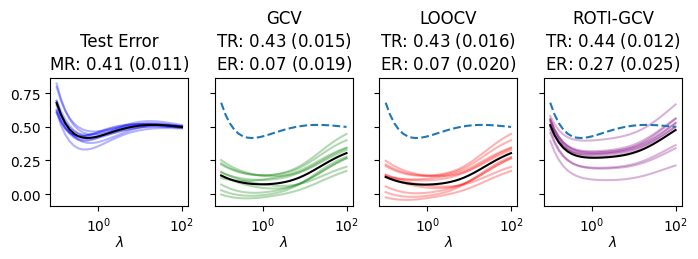

In [ ]:
h.plot_results(results_sp, lambdas, 1, filename = None, square=False)

## checks

In [ ]:
Qt, d, O = np.linalg.svd(X_train)
Qt_test, d_test, O_test = np.linalg.svd(X_test)

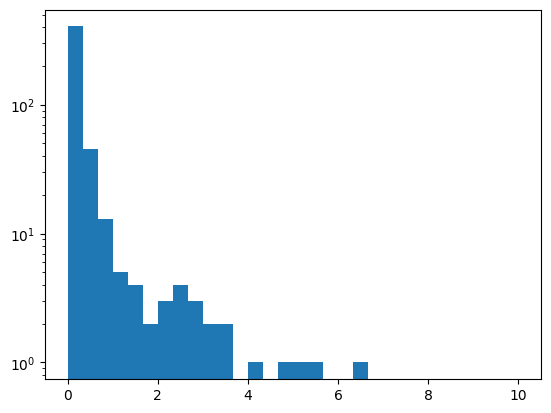

In [ ]:
plt.hist(d, bins = np.linspace(0, 10, 31))
plt.yscale("log")

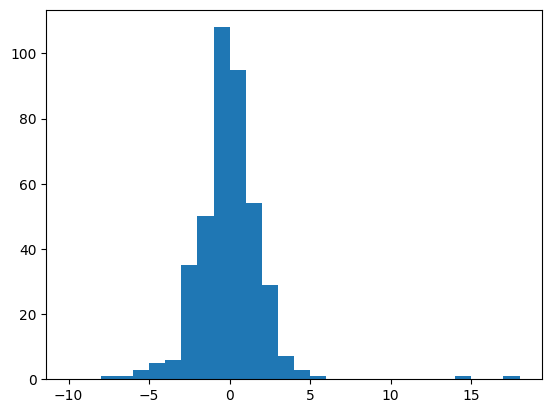

In [ ]:
plt.hist((O_test[:20] @ O[:20].T).flatten()* np.sqrt(p), np.linspace(-10, 18, 29) )
plt.show()

In [ ]:

pd.DataFrame(O_test[:10] @ O[:10].T * np.sqrt(p)).abs().round(2).style.background_gradient(cmap="Reds",vmin = 0, vmax = 10).format("{:.2f}")

,0,1,2,3,4,5,6,7,8,9
0,17.23,0.72,6.28,0.83,5.87,0.81,0.09,1.50,2.62,0.92
1,2.43,14.25,2.60,2.23,7.61,1.30,0.22,0.44,1.31,2.82
2,2.84,1.22,4.16,0.66,4.22,0.53,2.07,0.91,0.14,1.72
3,0.98,0.23,2.43,1.02,0.59,2.43,2.76,3.61,2.42,2.53
4,2.93,5.62,0.95,0.20,4.00,2.27,0.38,1.33,1.66,0.99
5,0.55,1.36,3.18,1.12,0.45,0.47,1.69,4.63,2.42,0.16
6,0.27,2.26,0.77,1.39,0.10,5.56,4.25,0.01,2.62,0.70
7,0.84,2.36,4.40,2.90,1.23,1.78,2.30,0.32,0.08,1.14
8,4.29,0.49,3.59,2.41,0.19,3.29,1.87,0.29,0.21,0.46
9,2.83,0.50,1.18,0.37,0.54,0.72,1.14,0.43,0.38,0.67


In [ ]:
formatter(pd.DataFrame(O_test[:10] @ O[:10].T * np.sqrt(p)), vmax = 10)

,$\tilde{o}_{1}$,$\tilde{o}_{2}$,$\tilde{o}_{3}$,$\tilde{o}_{4}$,$\tilde{o}_{5}$,$\tilde{o}_{6}$,$\tilde{o}_{7}$,$\tilde{o}_{8}$,$\tilde{o}_{9}$,$\tilde{o}_{10}$
$o_{1}$,{17.23},{2.43},{2.84},{0.98},{2.93},{0.55},{0.27},{0.84},{4.29},{2.83}
$o_{2}$,{0.72},{14.25},{1.22},{0.23},{5.62},{1.36},{2.26},{2.36},{0.49},{0.50}
$o_{3}$,{6.28},{2.60},{4.16},{2.43},{0.95},{3.18},{0.77},{4.40},{3.59},{1.18}
$o_{4}$,{0.83},{2.23},{0.66},{1.02},{0.20},{1.12},{1.39},{2.90},{2.41},{0.37}
$o_{5}$,{5.87},{7.61},{4.22},{0.59},{4.00},{0.45},{0.10},{1.23},{0.19},{0.54}
$o_{6}$,{0.81},{1.30},{0.53},{2.43},{2.27},{0.47},{5.56},{1.78},{3.29},{0.72}
$o_{7}$,{0.09},{0.22},{2.07},{2.76},{0.38},{1.69},{4.25},{2.30},{1.87},{1.14}
$o_{8}$,{1.50},{0.44},{0.91},{3.61},{1.33},{4.63},{0.01},{0.32},{0.29},{0.43}
$o_{9}$,{2.62},{1.31},{0.14},{2.42},{1.66},{2.42},{2.62},{0.08},{0.21},{0.38}
$o_{10}$,{0.92},{2.82},{1.72},{2.53},{0.99},{0.16},{0.70},{1.14},{0.46},{0.67}


In [ ]:
print(replace_latex_colors(formatter(pd.DataFrame(O_test[:10] @ O[:10].T * np.sqrt(p)), vmax = 10).to_latex()))

{\tiny
\setlength\tabcolsep{1.5pt}\renewcommand{\arraystretch}{1.5}
\sffamily
\begin{tabular}{p{1.5em}C{2.5em}C{2.5em}C{2.5em}C{2.5em}C{2.5em}C{2.5em}C{2.5em}C{2.5em}C{2.5em}C{2.5em}}
 & $\tilde{o}_{1}$ & $\tilde{o}_{2}$ & $\tilde{o}_{3}$ & $\tilde{o}_{4}$ & $\tilde{o}_{5}$ & $\tilde{o}_{6}$ & $\tilde{o}_{7}$ & $\tilde{o}_{8}$ & $\tilde{o}_{9}$ & $\tilde{o}_{10}$ \\
$o_{1}$ & \cellcolor[HTML]{67000d} \textcolor[HTML]{f1f1f1}{17.23} & \cellcolor[HTML]{fcbda4} \textcolor[HTML]{000000}{2.43} & \cellcolor[HTML]{fcb095} \textcolor[HTML]{000000}{2.84} & \cellcolor[HTML]{fee5d8} \textcolor[HTML]{000000}{0.98} & \cellcolor[HTML]{fcad90} \textcolor[HTML]{000000}{2.93} & \cellcolor[HTML]{ffece3} \textcolor[HTML]{000000}{0.55} & \cellcolor[HTML]{fff1ea} \textcolor[HTML]{000000}{0.27} & \cellcolor[HTML]{fee7dc} \textcolor[HTML]{000000}{0.84} & \cellcolor[HTML]{fc8161} \textcolor[HTML]{f1f1f1}{4.29} & \cellcolor[HTML]{fcb095} \textcolor[HTML]{000000}{2.83} \\
$o_{2}$ & \cellcolor[HTML]{fee9df} \tex

# detecting alignment

In [ ]:
np.random.seed(0)

p = 400
n = 400
lambdas = np.logspace(-1, 2, 30)


In [ ]:
np.random.seed(0)

k = 5
beta_unaligned = h.beta_sampler(p, r = 1 * np.sqrt(n))
alphas = 10 * np.ones(k)  # (np.sqrt(n) * (np.arange(k) + 1) / k)[::-1] / 5
beta_aligned = np.zeros(p)
for i in range(k):
    beta_aligned += alphas[i] * O[i]

beta = beta_unaligned + beta_aligned

In [ ]:
alphas

array([10., 10., 10., 10., 10.])

## computing the necessary parameters

In [ ]:
match_dict = {
    0: 0,
    1: 1,
    2: 2,
    3: 5, 
    4: 4,
    5: 3,
    6: 6,
    7: 7,
    8: 8,
    9: 9,
}

matcher = lambda d: match_dict[d]

In [ ]:
np.random.seed(1)
y_test = speech_test @ beta
lambdas = np.logspace(-1, 2, 30)
speech_result = h.gcv_test_pipeline(
    X_train = speech_train,
    y_train = None,
    X_test = speech_test,
    y_test = y_test,
    lambdas = lambdas,
    r = r,
    sigma = s,
    k = 10,
    true_beta = beta,
    n_iters = 1,
    oracle_test=False,
    matcher = matcher
)

Computing SVDs
Done computing SVDs
PCR Coefs: [ 9.75367217  9.1388209  10.59359662  9.9370305  10.31695823  0.14343388
  0.92941734 -0.77523011 -0.18701907 -1.44772269]
update
1.0
0.9037183729799415
1.0879072787283188 0.8945632148635171
[ 9.75367217  9.1388209  10.59359662  9.9370305  10.31695823  0.14343388
  0.92941734 -0.77523011 -0.18701907 -1.44772269]


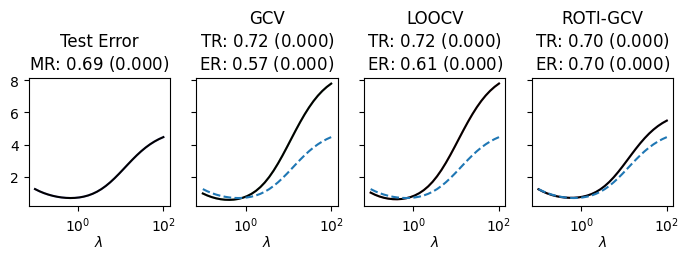

In [ ]:
h.plot_results(speech_result, lambdas, 1, None, square=False,)

In [ ]:
sigma_est = 0.8945632148635171
r2_est = 1.0879072787283188
pcr_coefs = [ 9.75367217  , 9.1388209  , 10.59359662  , 9.9370305  , 10.31695823  , 0.14343388
  , 0.92941734 , -0.77523011 , -0.18701907 , -1.44772269]
 

# sigma_est = 1.0233221704347222
# r2_est = 0.8929140472216904
# pcr_coefs = [10.14710685 , 10.54926189 , 11.43527988  , 8.91203207  , 9.136985    , 0.26681111 , 1.09215369 , -0.77411815 , -1.08413017  , 1.18799094]
# pcr_coefs = [ 4.14710685,  4.54926189,  5.43527988 , 2.91203207 , 3.136985 ,   0.26681111,
  # 1.09215369 ,-0.77411815, -1.08413017 , 1.18799094]

# sigma_est = 0.9700185521159821
# r2_est = 0.9755297026544592
# pcr_coefs = np.array([19.70457536, 15.24105288, 11.61569479,  7.44240039,  4.85584121, -1.03574247,
#  -0.84393259, -2.6481698,  -0.64301101, -0.64778423,])

In [ ]:
Qt, d, O = np.linalg.svd(speech_train)

In [ ]:
sis = np.sqrt(sigma_est * d[:10] + r2_est)

In [ ]:
stats = pcr_coefs / sis

In [ ]:
from scipy.stats import norm

In [ ]:
ps = 2 - 2 * norm.cdf(np.abs(stats))

In [ ]:
ps

array([9.61859230e-07, 5.34136247e-07, 3.17720872e-09, 1.77350421e-08,
       3.99026501e-09, 9.34322709e-01, 5.88302098e-01, 6.51054620e-01,
       9.12918150e-01, 3.95138415e-01])

In [ ]:
ps.round(2)

array([0.  , 0.  , 0.  , 0.  , 0.  , 0.93, 0.59, 0.65, 0.91, 0.4 ])

In [ ]:
angles = np.arccos((O @ beta)[:10] / (beta ** 2).sum() ** 0.5) * 180 / np.pi

In [ ]:
asdf = pd.DataFrame({"angle": angles, "p": ps})
asdf.index = asdf.index + 1


asdf_str = asdf.style.format({"angle": "{:.2f}", "p": "{:.3f}"}).to_latex()

In [ ]:
asdf

,angle,p
1,70.587830,9.618592e-07
2,71.807677,5.341362e-07
3,69.119105,3.177209e-09
4,69.252649,1.773504e-08
5,71.366534,3.990265e-09
6,89.821607,9.343227e-01
7,88.090649,5.883021e-01
8,90.763624,6.510546e-01
9,90.194746,9.129181e-01
10,93.383292,3.951384e-01


In [ ]:
print(asdf_str)

\begin{tabular}{lrr}
 & angle & p \\
1 & 70.59 & 0.000 \\
2 & 71.81 & 0.000 \\
3 & 69.12 & 0.000 \\
4 & 69.25 & 0.000 \\
5 & 71.37 & 0.000 \\
6 & 89.82 & 0.934 \\
7 & 88.09 & 0.588 \\
8 & 90.76 & 0.651 \\
9 & 90.19 & 0.913 \\
10 & 93.38 & 0.395 \\
\end{tabular}



In [ ]:
import numpy as np

def p_adjust_bh(p):
    """Benjamini-Hochberg p-value correction for multiple hypothesis testing."""
    p = np.asfarray(p)
    by_descend = p.argsort()[::-1]
    by_orig = by_descend.argsort()
    steps = float(len(p)) / np.arange(len(p), 0, -1)
    q = np.minimum(1, np.minimum.accumulate(steps * p[by_descend]))
    return q[by_orig]


In [ ]:
p_adjust_bh(ps).round(2)

array([0.  , 0.  , 0.  , 0.  , 0.  , 0.93, 0.81, 0.81, 0.93, 0.66])

In [ ]:
np.random.seed(1)
y_test = speech_test @ beta
lambdas = np.logspace(-1, 2, 30)
speech_result = h.gcv_test_pipeline(
    X_train = speech_train,
    y_train = None,
    X_test = speech_test,
    y_test = y_test,
    lambdas = lambdas,
    r = r,
    sigma = s,
    k = 5,
    true_beta = beta,
    n_iters = 10,
    oracle_test=False,
    matcher = matcher
)

Computing SVDs
Done computing SVDs
PCR Coefs: [ 9.75367217  9.1388209  10.59359662  9.9370305  10.31695823]
update
1.0
0.9331484791544697
1.0286292656142397 0.9093447524147766
[ 9.75367217  9.1388209  10.59359662  9.9370305  10.31695823]
PCR Coefs: [10.12314128  9.28611692 10.26534542 10.2304408  10.03743077]
update
1.0
0.9331484791544697
0.8104929332807979 0.9663819687589197
[10.12314128  9.28611692 10.26534542 10.2304408  10.03743077]
PCR Coefs: [10.27081644  8.87312751 10.00708381 11.35666532  9.12571156]
update
1.0
0.9331484791544697
0.9525997986808343 0.8631399473454368
[10.27081644  8.87312751 10.00708381 11.35666532  9.12571156]
PCR Coefs: [ 9.94930074  9.44697361 11.22045808 10.60035867 10.15007085]
update
1.0
0.9331484791544697
0.8784035255194911 1.182970113792586
[ 9.94930074  9.44697361 11.22045808 10.60035867 10.15007085]
PCR Coefs: [ 9.84820096  9.39125586 10.87913663 10.65251739  9.94620595]
update
1.0
0.9331484791544697
0.8454948511518551 1.0115609833353165
[ 9.84820096 

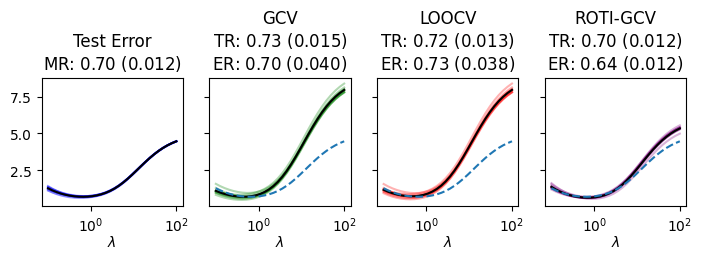

In [ ]:
h.plot_results(speech_result, lambdas, 1, None, square=False,)